#  Baseline Email Assistant

This lesson builds an email assistant that:
- Classifies incoming messages (respond, ignore, notify)
- Drafts responses
- Schedules meetings

We'll start with a **baseline implementation** — one that uses hard-coded rules and no memory. The goal is to establish a working end-to-end pipeline that we can measure and then improve in later lessons.

> **Why baseline first?** You can't improve what you can't measure. Building a simple working system lets us identify exactly where it fails — hallucinations, wrong classifications, no user review — before adding complexity.



---
## Research Overview

### Research Question
Can a two-stage LLM pipeline (cheap classifier → capable agent) effectively manage email with appropriate tool use, while keeping cost proportional to task complexity?

### System Architecture

| Component | Model | Responsibility |
|-----------|-------|---------------|
| **Triage Router** | `gpt-4o-mini` | Classify email intent: ignore / notify / respond |
| **Response Agent** | `gpt-4o` | Draft reply using ReAct reasoning loop + tools |

### Key Design Decisions

| Decision | Rationale |
|----------|-----------|
| Two-model split | Classification is cheap — use a small model; generation is hard — use a capable one |
| `with_structured_output(Router)` | Enforces Pydantic schema on LLM output — eliminates free-text parsing |
| LangGraph `Command` return | Router controls both the next node **and** the state update in one atomic return |
| `add_messages` reducer | Nodes append to message history — never overwrite; safe for multi-turn agents |
| Placeholder tools | `write_email`, `schedule_meeting`, `check_calendar_availability` — stub responses for POC |

### Concepts Introduced
- **LangGraph `StateGraph`** — directed graph where nodes are functions operating on shared state
- **`Command`** — return type that combines `goto` (routing) + `update` (state mutation)
- **ReAct loop** — Reason → Act (tool call) → Observe (tool result) → repeat until done
- **Structured output** — LLM constrained to return a Pydantic-validated object

---

In [117]:
import base64
from IPython.display import Image, HTML, display

def render_mermaid(diagram: str, title: str = "", caption: str = "") -> None:
    """Render a Mermaid diagram as a PNG image via mermaid.ink.

    Uses the mermaid.ink rendering service instead of loading mermaid.js from CDN,
    which is unreliable in Jupyter due to startOnLoad race conditions and duplicate
    script loads across cells.

    Args:
        diagram:  Mermaid source code (the content you would put in a ```mermaid block).
        title:    Optional <h4> heading shown above the diagram.
        caption:  Optional explanatory text shown below the diagram.
    """
    if title:
        display(HTML(f'<h4 style="font-family:sans-serif;margin-bottom:6px">{title}</h4>'))
    encoded = base64.urlsafe_b64encode(diagram.strip().encode("utf-8")).decode("ascii")
    display(Image(url=f"https://mermaid.ink/img/{encoded}?type=png"))
    if caption:
        display(HTML(f'<p style="font-family:sans-serif;font-size:13px;color:#6b7280;margin-top:6px">{caption}</p>'))

In [118]:
render_mermaid("""
flowchart TD
    EMAIL([Incoming Email\nauthor · to · subject · body])

    subgraph GRAPH["LangGraph StateGraph — email_agent"]
        direction LR
        TR["Triage Router\ngpt-4o-mini\nclassify intent"]
        RA["Response Agent\ngpt-4o\nReAct loop"]
        TR -->|respond| RA
        TR -->|ignore| IGNORE([END: ignored])
        TR -->|notify| NOTIFY([END: notified])
    end

    subgraph TOOLS["Tool Layer (stubs)"]
        direction TB
        T1[write_email]
        T2[schedule_meeting]
        T3[check_calendar_availability]
    end

    subgraph STATE["Shared State"]
        direction TB
        S1[email_input: dict]
        S2["messages: list\nadd_messages reducer"]
    end

    EMAIL --> GRAPH
    RA <-->|tool calls / results| TOOLS
    GRAPH <--> STATE
    RA --> SENT([Email Sent / Meeting Scheduled])

    style TR fill:#dbeafe,stroke:#3b82f6,color:#1e3a8a
    style RA fill:#dcfce7,stroke:#16a34a,color:#14532d
    style TOOLS fill:#fefce8,stroke:#ca8a04
    style STATE fill:#f9fafb,stroke:#d1d5db
    style IGNORE fill:#fee2e2,stroke:#ef4444
    style NOTIFY fill:#fef9c3,stroke:#ca8a04
""",
title="High-Level System Architecture",
caption=(
    "<b>Two-model split:</b> gpt-4o-mini handles cheap classification; "
    "gpt-4o handles expensive generation. Cost is proportional to task complexity. "
    "Shared State holds <code>email_input</code> (written once) and "
    "<code>messages</code> (append-only via <code>add_messages</code> reducer)."
))

<div style="background-color:#fff6ff; padding:13px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px">
<p> 💻 &nbsp; <b>Access <code>requirements.txt</code> , notebooks and other files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>.

<p> ⬇ &nbsp; <b>Download Notebooks:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Download as"</em> and select <em>"Notebook (.ipynb)"</em>.</p>

<p> 📒 &nbsp; For more help, please see the <em>"Appendix – Tips, Help, and Download"</em> Lesson.</p>

</div>

<p style="background-color:#f7fff8; padding:15px; border-width:3px; border-color:#e0f0e0; border-style:solid; border-radius:6px"> 🚨
&nbsp; <b>Different Run Results:</b> The output generated by AI chat models can vary with each execution due to their dynamic, probabilistic nature. Don't be surprised if your results differ from those shown in the video.</p>

## Step 1: Load API Tokens

Before running any LLM calls we need credentials for the external services this assistant uses.

`python-dotenv` reads a `.env` file from the project root and injects its key-value pairs into `os.environ`. This keeps secrets out of source code. Your `.env` should contain at minimum:

```
OPENAI_API_KEY=sk-...
```

The `load_dotenv()` call happens once at startup — all subsequent LangChain/LangGraph calls will find these values automatically via `os.getenv(...)`.

In [119]:
import os
from dotenv import load_dotenv
_ = load_dotenv()

## Step 2: Define the User Profile, Triage Rules, and a Sample Email

### Why a `profile` dict?
The assistant needs to know *who* it's working for. The `profile` values are injected into both the triage and response-agent system prompts via `{name}`, `{full_name}`, and `{user_profile_background}` placeholders. The same code and graph can serve entirely different users by changing only this dict.

### Why keep triage rules separate?
`prompt_instructions["triage_rules"]` lives outside the prompt template text intentionally — it acts as **runtime configuration**. Updating the rules (e.g. adding a new `ignore` category) requires changing only this dict, not the prompt template or the graph.

### The sample emails
We'll test two emails that cover opposite classifications:
1. A spam/marketing email → expected: `ignore` (gpt-4o never invoked)
2. A direct question from a colleague → expected: `respond` (full ReAct loop runs)

In [120]:
profile = {
    "name": "John",
    "full_name": "John Doe",
    "user_profile_background": "Senior software engineer leading a team of 5 developers",
}

In [121]:
prompt_instructions = {
    "triage_rules": {
        "ignore": "Marketing newsletters, spam emails, mass company announcements",
        "notify": "Team member out sick, build system notifications, project status updates",
        "respond": "Direct questions from team members, meeting requests, critical bug reports",
    },
    "agent_instructions": "Use these tools when appropriate to help manage John's tasks efficiently."
}

In [122]:
# Example incoming email
email = {
    "from": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "body": """
Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

## Step 3: Build the Triage Router

**What is triage?** The word comes from emergency medicine — quickly sorting patients by severity so limited resources go where they're most needed. Here we apply the same idea to email: a cheap, fast model reads each incoming email and sorts it into one of three buckets *before* the expensive model ever runs.

### The three buckets

| Label | Meaning | What happens |
|-------|---------|--------------|
| `ignore` | Spam, newsletters, mass announcements | Graph ends immediately — no LLM cost beyond classification |
| `notify` | Important info that needs no reply (OOO, CI alerts) | Graph ends — in production this would trigger a notification |
| `respond` | Direct questions, meeting requests, bug reports | Email is forwarded to the response agent |

### What we build in this section

1. **`Router` Pydantic schema** — defines the exact output shape we expect from the LLM. Using `Literal["ignore", "respond", "notify"]` as the type means the LLM is forced to return one of exactly three strings.
2. **`llm_router`** — a gpt-4o-mini instance bound to that schema via `with_structured_output(Router)`. The model cannot return free text; it must fill the schema.
3. **Triage prompts** — a system prompt (rules + user profile) and a user prompt (the email being classified). These are loaded from `prompts.py` as reusable templates.

### Key concept: structured output
Normally an LLM returns a plain string. `with_structured_output(Router)` changes this: LangChain internally uses function-calling to instruct the model to fill a JSON object that matches the Pydantic schema. The result you get back is a validated Python object — not a string you have to parse.

In [123]:
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal, Annotated
from langchain.chat_models import init_chat_model

In [124]:
llm = init_chat_model("openai:gpt-4o-mini")

In [125]:
class Router(BaseModel):
    """Analyze the unread email and route it according to its content."""

    # The LLM is asked to show its reasoning before giving a classification.
    # This is a form of chain-of-thought prompting — forcing the model to reason
    # step-by-step before committing to an answer improves classification accuracy.
    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )

    # Literal constrains the field to exactly three allowed values.
    # The LLM cannot return anything else — if it tries, Pydantic raises a ValidationError.
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

In [126]:
# Bind gpt-4o-mini to the Router schema.
# with_structured_output() uses OpenAI function-calling under the hood:
# it passes the Pydantic schema as a function definition to the API, so the model
# is instructed to return structured JSON matching that schema rather than plain text.
# The result of llm_router.invoke(...) is always a Router object — never a raw string.
llm_router = llm.with_structured_output(Router)

In [127]:
render_mermaid("""
flowchart TD
    IN([Incoming email\nauthor · subject · body]) --> SYS[Build system prompt\nwith triage rules + profile]
    SYS --> LLM[gpt-4o-mini\nwith_structured_output Router]
    LLM --> OUT{classification}

    OUT -->|ignore| IG["Marketing / spam\nno action → END"]
    OUT -->|notify| NT["Status update / OOO\nlog → END"]
    OUT -->|respond| RS["Direct question / meeting request\n→ response_agent"]

    subgraph Schema["Router Pydantic schema"]
        direction LR
        F1["reasoning: str\nstep-by-step thinking"]
        F2["classification: Literal\nignore | notify | respond"]
    end

    LLM -.->|structured output| Schema

    style LLM fill:#dbeafe,stroke:#3b82f6
    style RS  fill:#dcfce7,stroke:#16a34a
    style IG  fill:#fee2e2,stroke:#ef4444
    style NT  fill:#fef9c3,stroke:#ca8a04
    style Schema fill:#f9fafb,stroke:#d1d5db
""",
title="Triage Decision Logic",
caption=(
    "<b>Why structured output?</b> "
    "<code>llm.with_structured_output(Router)</code> forces the LLM to return a "
    "Pydantic-validated object. The <code>classification</code> field is guaranteed "
    "to be one of <code>ignore | notify | respond</code> — no free-text parsing needed."
))

In [128]:
from prompts import triage_system_prompt, triage_user_prompt

In [129]:
# View the raw prompt templates before we fill in the placeholders.
# The {curly_brace} variables are Python str.format() placeholders — they are
# filled at runtime with the user profile and email content.
# Note the {examples} placeholder: it's currently set to None (empty), but in
# later lessons this will hold few-shot examples drawn from memory to improve accuracy.
print("=== triage_system_prompt ===")
print(triage_system_prompt)
print("=== triage_user_prompt ===")
print(triage_user_prompt)

=== triage_system_prompt ===
You are an email assistant for {full_name}. Your job is to triage incoming emails and classify them.

About {name}:
{user_profile_background}

Classify each email into exactly one of these categories:

IGNORE: {triage_no}
NOTIFY: {triage_notify}
RESPOND: {triage_email}

{examples}

Reason step by step before giving your final classification.

=== triage_user_prompt ===
Please classify the following email:

From: {author}
To: {to}
Subject: {subject}

Email body:
{email_thread}



In [130]:
# Build the system prompt by filling in the template placeholders.
# examples=None renders as the string "None" in the prompt — harmless for the baseline,
# but in Lesson 3 this slot will hold retrieved few-shot examples from episodic memory.
system_prompt = triage_system_prompt.format(
    full_name=profile["full_name"],
    name=profile["name"],
    examples=None,
    user_profile_background=profile["user_profile_background"],
    triage_no=prompt_instructions["triage_rules"]["ignore"],
    triage_notify=prompt_instructions["triage_rules"]["notify"],
    triage_email=prompt_instructions["triage_rules"]["respond"],
)

In [131]:
user_prompt = triage_user_prompt.format(
    author=email["from"],
    to=email["to"],
    subject=email["subject"],
    email_thread=email["body"],
)

In [132]:
result = llm_router.invoke(
    [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]
)

In [133]:
print(result)

reasoning="This email is a direct question from a team member (Alice Smith) regarding the API documentation. Alice is seeking clarification on specific endpoints which indicates it's important and needs a response. Therefore, it falls under the 'respond' category." classification='respond'


## Step 4: Define the Response Agent's Tools

Tools are Python functions that the LLM can choose to call during its reasoning loop. LangGraph exposes them to the model as structured function-call options and automatically handles:
- Converting the model's JSON argument choices into Python keyword arguments
- Executing the function and capturing the return value
- Injecting the result back into the conversation as a `ToolMessage`

### How the LLM decides which tool to call
The `@tool` decorator inspects the function's **type annotations** (to generate the JSON parameter schema) and **docstring** (to describe the tool's purpose to the LLM). The docstring is your tool's description — the model uses it to decide *when* to call the tool, so write it precisely.

### Stub vs. real implementations
All three tools return hardcoded strings. This is intentional for a proof-of-concept:
- It lets us verify the agent's *reasoning* (did it pick the right tool with the right arguments?) without needing real email or calendar infrastructure.
- Swapping in real implementations later only requires changing the function bodies — the agent, the graph, and all routing logic stay the same.

```
write_email(to, subject, content)        → would call SMTP / Gmail API
schedule_meeting(attendees, ...)         → would call Google Calendar API  
check_calendar_availability(day)         → would call Calendar read API
```

In [134]:
from langchain_core.tools import tool
# langgraph.prebuilt.create_react_agent is deprecated in LangGraph V1.0 but remains
# the only variant that accepts a callable prompt= (a function that takes state and
# returns a message list). langchain.agents.create_agent expects a ChatPromptTemplate,
# not a function, so it cannot be used as a drop-in replacement here.
from langgraph.prebuilt import create_react_agent  # noqa: F401  (deprecation warning suppressed below)

In [135]:
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}'"

In [136]:
@tool
def schedule_meeting(
    attendees: list[str], 
    subject: str, 
    duration_minutes: int, 
    preferred_day: str
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    return f"Meeting '{subject}' scheduled for {preferred_day} with {len(attendees)} attendees"



In [137]:
@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

## Step 5: Build the Agent's Dynamic System Prompt

Unlike the triage router — which uses a static, pre-formatted prompt — the response agent's prompt is **built fresh on every node invocation** from the live graph state.

### Why a function, not a string?
`create_prompt(state)` is called by LangGraph each time the `response_agent` node runs. It returns a complete message list:

```
[system_message]  +  state["messages"]
     ↑                      ↑
always prepended       all prior turns
(identity/rules)       (conversation history)
```

This pattern lets you inject **dynamic context** — user profile, current date/time, retrieved documents from a database, etc. — without modifying the graph structure. The agent always sees an up-to-date system prompt.

### How `create_agent` uses this function
When you pass `prompt=create_prompt` to `create_agent(...)`, LangGraph will call `create_prompt(state)` before every LLM call in the ReAct loop. The function receives the full current state, so it can pull in whatever context is needed at that moment.

In [138]:
from prompts import agent_system_prompt

def create_prompt(state):
    # Called by LangGraph before every LLM step in the ReAct loop.
    # Returns the full message list the model will see:
    #   [system_message] + all prior messages in state
    #
    # The **profile unpacking injects name, full_name, and user_profile_background
    # into the system prompt template, personalising the agent for the current user.
    return [
        {
            "role": "system", 
            "content": agent_system_prompt.format(
                instructions=prompt_instructions["agent_instructions"],
                **profile
            )
        }
    ] + state['messages']

In [139]:
print(agent_system_prompt)

You are a helpful email assistant for {full_name}.

About {name}:
{user_profile_background}

Your job is to help {name} manage their email efficiently. You can:
- Write and send emails
- Schedule meetings
- Check calendar availability

Instructions: {instructions}

Always be professional and concise. When drafting replies, match the tone of the original email.



In [140]:
tools=[write_email, schedule_meeting, check_calendar_availability]

In [141]:
import warnings
# Suppress the V1.0 deprecation warning: create_react_agent is kept here intentionally
# because it is the only LangGraph API that accepts a callable prompt function.
# The suggested replacement (langchain.agents.create_agent) requires a ChatPromptTemplate
# and cannot replicate the dynamic state-aware prompt pattern used in create_prompt().
warnings.filterwarnings("ignore", message=".*create_react_agent.*")

agent = create_react_agent(
    "openai:gpt-4o",
    tools=tools,
    prompt=create_prompt,
)

In [142]:
# Quick sanity check: invoke the agent standalone (outside the full email_agent graph)
# to verify the ReAct loop + tools work correctly before wiring everything together.
# The agent should call check_calendar_availability("tuesday") and return the result.
response = agent.invoke(
    {"messages": [{
        "role": "user", 
        "content": "what is my availability for tuesday?"
    }]}
)

In [143]:
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

You're available on Tuesday at the following times:
- 9:00 AM
- 2:00 PM
- 4:00 PM


### LangGraph State & Message Flow

The `State` TypedDict is the shared data structure that flows through every node:

| Field | Type | Reducer | Description |
|-------|------|---------|-------------|
| `email_input` | `dict` | replace | Original email — written once at invocation, read by `triage_router` |
| `messages` | `list` | `add_messages` | Append-only message history — each node appends, never overwrites |

**Why `add_messages`?**  
LangGraph's `add_messages` reducer merges message lists by ID. Nodes return only *new* messages — the graph handles concatenation. Without it, each node would overwrite the full message list, losing prior context.

**Message accumulation through a full `respond` run:**
```
triage_router   → reads  email_input (author, subject, body)
                → appends HumanMessage("Respond to email {…}")

response_agent  → reads  messages[]
                → calls  write_email(to, subject, content)   ← tool call
                → appends ToolMessage("Email sent to …")     ← tool result
                → appends AIMessage("I've sent the reply…")  ← final answer
```

The sequence diagram in the cell below shows this flow visually.

In [144]:
# Diagram A — graph-level routing
# Bug fix: original used `subgraph RA[...]` with the same ID as the node `RA`,
# causing Mermaid to silently misrender the subgraph. Renamed to REACT_LOOP.
render_mermaid("""
flowchart LR
    START([START]) --> TR[triage_router]
    TR -->|respond| AGENT[response_agent]
    TR -->|ignore / notify| DONE([END])
    AGENT --> DONE

    subgraph REACT_LOOP[response_agent — ReAct loop]
        direction TB
        LLM2[gpt-4o\nreason + plan]
        LLM2 -->|tool_call| TC[Tool execution]
        TC -->|tool_result| LLM2
        LLM2 -->|no more tools| FINAL[Final AIMessage]
    end

    style TR fill:#dbeafe,stroke:#3b82f6,color:#1e3a8a
    style REACT_LOOP fill:#dcfce7,stroke:#16a34a
    style DONE fill:#f3f4f6,stroke:#9ca3af
""",
title="LangGraph: Overall State Flow",
caption=(
    "The <code>triage_router</code> node returns a <code>Command(goto=..., update=...)</code> "
    "that atomically sets the next node AND updates state. If classified as <em>respond</em>, "
    "the <code>response_agent</code> enters a ReAct loop: reason → tool call → observe → repeat."
))

# Diagram B — message accumulation inside the state
render_mermaid("""
sequenceDiagram
    participant ST as State
    participant TR as triage_router
    participant RA as response_agent
    participant WE as write_email tool

    TR->>ST: read email_input (author, subject, body)
    TR->>ST: append HumanMessage("Respond to email {…}")
    RA->>ST: read messages
    RA->>WE: tool call — write_email(to, subject, content)
    WE-->>ST: append ToolMessage(result="Email sent to …")
    RA->>ST: append AIMessage("I've sent the response…")
""",
title="State: Message Accumulation",
caption=(
    "The <code>add_messages</code> reducer merges messages by ID — nodes append new messages "
    "rather than overwriting the list. This makes the graph safe for multi-turn and parallel execution."
))

## Step 6: Define Shared State and the Triage Router Node

### What is `State`?
`State` is a `TypedDict` — a typed dictionary that defines **every piece of data that can flow between nodes** in the graph. Think of it as the working memory for a single run through the pipeline:

| Field | Type | Reducer | Role |
|-------|------|---------|------|
| `email_input` | `dict` | replace (default) | The raw incoming email. Written once at `invoke()`, never changed. |
| `messages` | `list` | `add_messages` | The conversation history. Each node appends; nothing is overwritten. |

### What is a reducer?
A **reducer** is a function that decides how to merge a new value into an existing state field. Instead of replacing the whole list, `add_messages` *appends* new messages and updates existing ones by ID. This is what makes the conversation history accumulate safely across multiple nodes and tool calls.

Without a reducer:
```python
# Node returns {"messages": [new_msg]}
# State["messages"] gets replaced — all prior messages lost!
```

With `add_messages`:
```python
# Node returns {"messages": [new_msg]}
# State["messages"] becomes old_messages + [new_msg]  ✓
```

### What does the `triage_router` node do?
This is the first node the graph runs after receiving an email. It:
1. Reads `author`, `to`, `subject`, `email_thread` from `state["email_input"]`
2. Formats the triage prompts with the user's profile and rules
3. Calls `llm_router` (gpt-4o-mini + structured output) to classify the email
4. Returns a `Command` that tells LangGraph **where to route next AND what to write to state** in a single atomic return

### Key concept: `Command`
Normally a LangGraph node returns a plain dict (`{"messages": [...]}`) that updates state, and edges defined at graph-build time determine routing. `Command` collapses both into one return value:

```python
return Command(
    goto="response_agent",   # ← routing decision (replaces edge logic)
    update={"messages": [...]}  # ← state mutation (same as a normal node return)
)
```

This is useful when the routing decision depends on runtime data (the LLM's classification) rather than static graph structure.

In [145]:
from langgraph.graph import add_messages

class State(TypedDict):
    email_input: dict
    messages: Annotated[list, add_messages]

In [146]:
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from IPython.display import Image, display
# Note: Literal is already imported from typing_extensions above

In [147]:
def triage_router(state: State) -> Command[
    Literal["response_agent", "__end__"]
]:
    author = state['email_input']['author']
    to = state['email_input']['to']
    subject = state['email_input']['subject']
    email_thread = state['email_input']['email_thread']

    system_prompt = triage_system_prompt.format(
        full_name=profile["full_name"],
        name=profile["name"],
        user_profile_background=profile["user_profile_background"],
        triage_no=prompt_instructions["triage_rules"]["ignore"],
        triage_notify=prompt_instructions["triage_rules"]["notify"],
        triage_email=prompt_instructions["triage_rules"]["respond"],
        examples=None
    )
    user_prompt = triage_user_prompt.format(
        author=author, 
        to=to, 
        subject=subject, 
        email_thread=email_thread
    )
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email {state['email_input']}",
                }
            ]
        }
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        update = {}
        goto = END
    elif result.classification == "notify":
        # If real life, this would do something else
        print("🔔 Classification: NOTIFY - This email contains important information")
        update = {}
        goto = END
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

## Step 7: Assemble, Compile, and Run the Graph

### Building the graph
A `StateGraph` is assembled declaratively — you describe the nodes and edges, then ask LangGraph to compile:

```python
email_agent = StateGraph(State)        # 1. create graph typed to our State schema
email_agent.add_node(triage_router)    # 2. register nodes (function name becomes node name)
email_agent.add_node("response_agent", agent)
email_agent.add_edge(START, "triage_router")   # 3. set the entry point
email_agent.compile()                  # 4. validate and freeze
```

We do **not** add an edge from `triage_router` to `response_agent` — that routing happens at runtime via `Command(goto=...)`. The only static edge we need is the entry point.

### What `compile()` validates
- Every node name referenced in `Command(goto=...)` or `add_edge(...)` actually exists
- The graph has a valid `START` entry point
- There are no isolated / unreachable nodes

Compilation also enables `draw_mermaid_png()` introspection (next cell), which renders the **actual compiled graph** — including LangGraph's internal ReAct subgraph nodes — not just our hand-drawn diagram.

### Running the graph
`email_agent.invoke({"email_input": email_input})` writes `email_input` into the initial state, then runs the graph synchronously until it reaches `END`. The return value is the final state dict — you can inspect `["messages"]` to see the full conversation trace.

In [148]:
# Assemble the graph declaratively:
#   add_node(triage_router)   — registers the function; node name = function name
#   add_node("response_agent", agent) — registers the pre-built ReAct agent subgraph
#   add_edge(START, "triage_router")  — every run starts here
#   compile()  — validates the graph structure and freezes it into an executable
#
# We do NOT add an edge from triage_router → response_agent.
# That routing is handled dynamically at runtime by Command(goto="response_agent")
# inside the triage_router function.
email_agent = StateGraph(State)
email_agent = email_agent.add_node(triage_router)
email_agent = email_agent.add_node("response_agent", agent)
email_agent = email_agent.add_edge(START, "triage_router")
email_agent = email_agent.compile()

Compiled graph nodes: ['__start__', 'triage_router', '__end__', 'response_agent:__start__', 'response_agent:agent', 'response_agent:tools', 'response_agent:__end__']



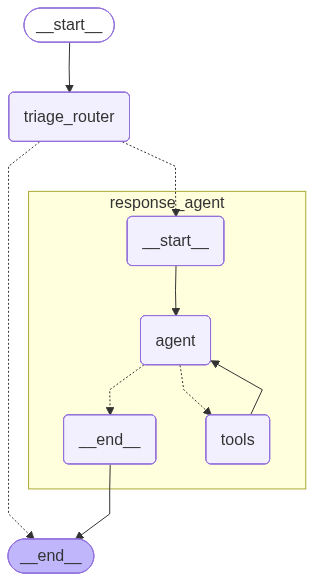

In [149]:
# Show the compiled LangGraph — xray=True expands sub-graphs (shows ReAct internals)
print("Compiled graph nodes:", list(email_agent.get_graph(xray=True).nodes.keys()))
print()
try:
    display(Image(email_agent.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # Fallback if playwright/pyppeteer not installed
    print(email_agent.get_graph(xray=True).draw_ascii())

In [150]:
email_input = {
    "author": "Marketing Team <marketing@amazingdeals.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "🔥 EXCLUSIVE OFFER: Limited Time Discount on Developer Tools! 🔥",
    "email_thread": """Dear Valued Developer,

Don't miss out on this INCREDIBLE opportunity! 

🚀 For a LIMITED TIME ONLY, get 80% OFF on our Premium Developer Suite! 

✨ FEATURES:
- Revolutionary AI-powered code completion
- Cloud-based development environment
- 24/7 customer support
- And much more!

💰 Regular Price: $999/month
🎉 YOUR SPECIAL PRICE: Just $199/month!

🕒 Hurry! This offer expires in:
24 HOURS ONLY!

Click here to claim your discount: https://amazingdeals.com/special-offer

Best regards,
Marketing Team
---
To unsubscribe, click here
""",
}

In [151]:
response = email_agent.invoke({"email_input": email_input})

🚫 Classification: IGNORE - This email can be safely ignored


In [152]:
email_input = {
    "author": "Alice Smith <alice.smith@company.com>",
    "to": "John Doe <john.doe@company.com>",
    "subject": "Quick question about API documentation",
    "email_thread": """Hi John,

I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?

Specifically, I'm looking at:
- /auth/refresh
- /auth/validate

Thanks!
Alice""",
}

In [153]:
response = email_agent.invoke({"email_input": email_input})

📧 Classification: RESPOND - This email requires a response


In [154]:
# Print the full message trace to see every step the agent took:
#   1. HumanMessage  — the task injected by triage_router ("Respond to email {...}")
#   2. AIMessage     — the agent's first response, which includes tool_calls
#   3. ToolMessage   — the result returned by write_email(...)
#   4. AIMessage     — the agent's final summary after observing the tool result
#
# This trace is what makes ReAct interpretable: you can see exactly what the
# agent decided to do and why, not just the final answer.
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Respond to the email {'author': 'Alice Smith <alice.smith@company.com>', 'to': 'John Doe <john.doe@company.com>', 'subject': 'Quick question about API documentation', 'email_thread': "Hi John,\n\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\n\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\n\nThanks!\nAlice"}
================================== Ai Message ==================================
Tool Calls:
  write_email (call_y5ZZTgOQs5OVv6YCmuQcQZDv)
 Call ID: call_y5ZZTgOQs5OVv6YCmuQcQZDv
  Args:
    to: alice.smith@company.com
    subject: Re: Quick question about API documentation
    content: Hi Alice,

Thanks for pointing this out. The endpoints /auth/refresh and /auth/validate should indeed be included in the documenta

---
## Observations & Research Findings

### Test Run 1 — Spam email
- **Input**: Marketing newsletter with discount offer from `amazingdeals.com`
- **Triage result**: `ignore` — graph terminated at `END`, response agent never invoked
- **Cost efficiency**: Only `gpt-4o-mini` was called — no expensive model used

### Test Run 2 — Alice's API question
- **Input**: Direct question from team member about missing auth endpoints
- **Triage result**: `respond` → forwarded to response agent
- **Agent action**: Called `write_email` tool with a professionally drafted reply
- **Hallucination observed**: Agent stated the endpoints were *"unintentionally left out"* — no such information was in the email; the agent invented a reason to fill the gap

### Quantitative Summary

| Metric | Result |
|--------|--------|
| Triage accuracy | 2 / 2 correct |
| Tool selection | Correct (`write_email`, not `schedule_meeting`) |
| Hallucination | Yes — agent fabricated a reason for missing endpoints |
| Cost routing | gpt-4o-mini for triage · gpt-4o for response — appropriate split |
| Latency hotspot | Response agent (gpt-4o + ReAct loop) |

### Limitations of this Baseline

1. **No memory** — Each email is handled in complete isolation. The agent has no knowledge of past interactions with Alice or the auth service project.
2. **Hallucination** — Without grounding facts, the agent fills gaps with plausible-but-wrong information.
3. **No human-in-the-loop** — The draft is sent immediately without John reviewing it.
4. **Static triage rules** — Rules are plain text strings; edge cases and nuanced emails will be misclassified.
5. **Notify is a no-op** — `classify: notify` only prints to stdout; no real notification mechanism exists.
6. **No feedback loop** — The agent cannot learn from John correcting bad drafts.

### What Lesson 3 Will Fix
- Persistent memory (episodic + semantic) so the agent learns user preferences
- Human-in-the-loop interrupt before emails are sent
- Contextual grounding from prior email threads